In [1]:
from mpasviewer import scvtmesh
import cartopy.crs as ccrs

In [2]:
path2data = 'sample_data'

mpasd = scvtmesh(grid_file=f'{path2data}/nyc_static/nyc.static.nc', 
                 diag_list=f'{path2data}/nyc_out')

In [3]:
mpasd.dataset(load_variables=['rainnc', 'rainc', 'precipw', 't2m', "uzonal",'olrtoa','refl10cm_max',])

Loaded grid_file dataset: sample_data/nyc_static/nyc.static.nc


In [4]:
mpasd.rain_rate()

In [5]:
dta = mpasd.load()

In [6]:
vars = ['t2m', 'olrtoa', 'refl10cm_max', 'rain_rate']
times = [str(x) for x in dta['time'].data.astype('datetime64[s]')]
num_steps = len(times)
# print(*times,sep=",")

In [7]:
from ipywidgets import interact, Dropdown, IntSlider, SelectionSlider
from IPython.display import display, clear_output

In [8]:
from earthcmap import escmap

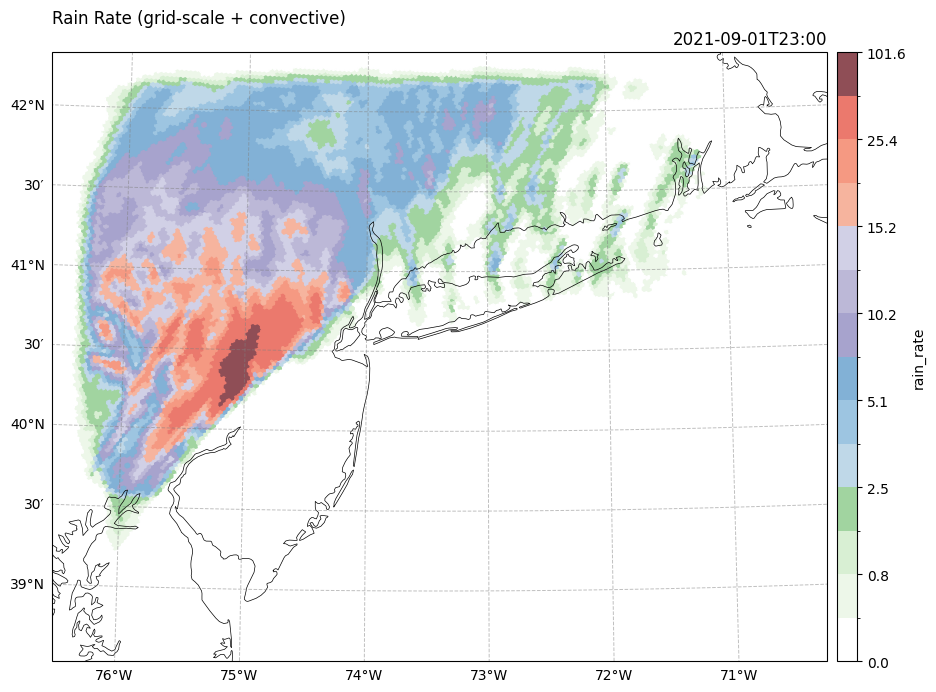

In [9]:
cmap, norm = escmap("wofs_prec", units="mm")
mpasd.show(dta,var_name='rain_rate',time_index='2021-09-01T23', cmap = cmap, norm = norm, figsize = (10, 10))

In [10]:
cmps = {'t2m':"temp_ecmwf", 'olrtoa':"wofs_ir", 'refl10cm_max':"wofs_radar", 'rain_rate':"wofs_prec"}

In [11]:
def update_plot(variable, time_step):
    cmap, norm = escmap(cmps[variable], units = dta[variable].attrs['units'])
    # print(cmap.name)
    mpasd.show(dta, var_name = variable, time_index = time_step, cmap = cmap, norm = norm, figsize = (8,8))
    # mpasd.show(dta,var_name='rain_rate',time_index='2021-09-01T23',figsize=(8,8))
# dropdown and slider widgets
variable_dropdown = Dropdown(options=vars, description='Variable:')
time_slider = SelectionSlider(
    options=times,
    value=times[5],
    description='Datetime:',
    layout={'width': '500px'},
    style={'description_width': 'initial'}
)

In [12]:
interact(update_plot, variable=variable_dropdown, time_step=time_slider)

interactive(children=(Dropdown(description='Variable:', options=('t2m', 'olrtoa', 'refl10cm_max', 'rain_rate')…

<function __main__.update_plot(variable, time_step)>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from earthcmap import escmap

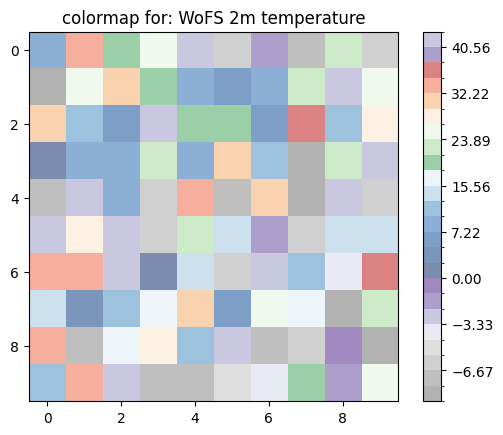

In [16]:
cmap_name = "temp_wofs"
     
cmap, norm = escmap(cmap_name, units="C")

values = cmap.positions

# Generate random matrix using values from the cbar
data = np.random.choice(values, size=(10, 10),)

# Plot
fig, ax = plt.subplots(dpi=100)
img = ax.imshow(data, cmap=cmap, norm=norm)
plt.title(f"colormap for: {cmap.long_name}")

cbar = plt.colorbar(img)

# cbar.set_ticks(cmap.positions)
# cbar.set_ticklabels(cmap.labels)

In [12]:
values

[-8.88888888888889,
 -7.777777777777778,
 -6.666666666666667,
 -5.555555555555555,
 -4.444444444444445,
 -3.3333333333333335,
 -2.2222222222222223,
 -1.1111111111111112,
 0.0,
 2.2222222222222223,
 4.444444444444445,
 7.222222222222222,
 10.0,
 12.777777777777779,
 15.555555555555555,
 18.333333333333332,
 21.11111111111111,
 23.88888888888889,
 26.666666666666668,
 29.444444444444443,
 32.22222222222222,
 35.0,
 37.77777777777778,
 40.55555555555556,
 81.11111111111111]